### Create the embedding from the py file
1. Upload the images
2. Create the global stats (all the tiles of each product (s1 or s2))
3. Normalize
4. Load the model
5. Use the encoder 
6. Save the .npy

In [ ]:
from make_embeddings import (
    embed_image,
    embed_image_joint,
    iter_joint_pairs_from_csv,
    load_model,
    load_or_compute_stats,
)
import numpy as np, glob, re

TILES_ROOT = "/share/castor/home/e2406749/thesis_tiles_120px"
CSV_PATH_V3   = "data_csv/v3_images_s2_s1.csv"
FID        = 153    # an example fid
TILE       = 0      # tile
MAX_GAP = 7

# calculate the stats just once
model    = load_model("joint")
s2_stats = load_or_compute_stats(TILES_ROOT, "s2_l2a")
s1_stats = load_or_compute_stats(TILES_ROOT, "s1_grd")


In [ ]:
#create the joint pairs
from collections import Counter
def check_pairs(FID, CSV_PATH):
    pairs = [p for p in iter_joint_pairs_from_csv(CSV_PATH, TILES_ROOT, max_gap_days=7)
        if p[0] == FID]
    print (pairs)
    print(f"FID {FID}: {len(pairs)} pairs")
    print(f"  Por window: {Counter(p[1] for p in pairs)}")
    print(f"  Gap stats: min={min(p[4] for p in pairs)}, max={max(p[4] for p in pairs)}")

#Number of pairs for version 3
check_pairs(FID, CSV_PATH_V3)

In [ ]:
# Number of pairs for version 2
CSV_PATH_V2 = "data_csv/v2_images_s2_s1.csv"

check_pairs(FID, CSV_PATH_V2)

In [ ]:
#Number of pairs for version 1
CSV_PATH_V1 = "data_csv/v1_images_s2_s1.csv"

check_pairs(FID, CSV_PATH_V1)


Gap status means the minimum and maximum day of the joint pairing

In [ ]:
model_optical = load_model("optical")
model_sar = load_model("sar")
model_joint = load_model("joint")

In [ ]:
# Generate embeddings for all FID pairs in the 3 modalities
pairs = [p for p in iter_joint_pairs_from_csv(CSV_PATH_V3, TILES_ROOT, max_gap_days=MAX_GAP)
        if p[0] == FID]
print(f"FID {FID}: {len(pairs)} pairs with gap <= {MAX_GAP} days")

# S2: used all the images (IT NEEDS TO BE CHANGE FOR CSV VERSION)
s2_dirs = sorted(glob.glob(f"{TILES_ROOT}/s2_l2a/fid_{FID}/*/*"))   # bef + evt + aft, todos los image_ids
for d in s2_dirs:
        embed_image(d, model=model_optical, stats=s2_stats)

# S1: Used all the images 
s1_dirs = sorted(glob.glob(f"{TILES_ROOT}/s1_grd/fid_{FID}/*/*"))
for d in s1_dirs:
        embed_image(d, model=model_sar, stats=s1_stats)

# Create the joint embeddings based on the CSV version 3
for fid, win, s2_dir, s1_dir, gap in iter_joint_pairs_from_csv(
        CSV_PATH_V3, TILES_ROOT, max_gap_days=MAX_GAP):
        if fid != FID: continue
        embed_image_joint(s2_dir, s1_dir, model=model_joint,
                s2_stats=s2_stats, s1_stats=s1_stats)

In [ ]:
emb = np.load(f"embeddings/joint/fid_{FID}/aft/20230515T142711_20230515T142713_T20LNR__S1A_IW_GRDH_1SDV_20230509T094912_20230509T094937_048455_05D42C_BB80/tile_0.npy")
print(emb.shape)        # (15, 15, 768)
print(emb.dtype)        # float32
print(emb.min(), emb.max(), emb.mean())
print(emb[0, 0, :10]) 

### Check the tile_0 embeddings in different modes

In [ ]:
# check the embeddings per tile 0 in the joint time series 
import glob
paths = sorted(glob.glob(f"embeddings/joint/fid_{FID}/*/*/tile_0.npy"))
for p in paths:
    print(p)

In [ ]:
paths = sorted(glob.glob(f"embeddings/s1_grd/fid_{FID}/*/*/tile_0.npy"))
for p in paths:
    print(p)

In [ ]:
paths = sorted(glob.glob(f"embeddings/s2_l2a/fid_{FID}/*/*/tile_0.npy"))
for p in paths:
    print(p)

### Plot of the embedding

In [ ]:
import numpy as np 
import matplotlib.pyplot as plt

emb = np.load("embeddings/s2_l2a/fid_153/aft/20230515T142711_20230515T142713_T20LNR/tile_0.npy")
print("shape:", emb.shape)            # (15, 15, 768)
print("min:", emb.min(), "max:", emb.max(), "mean:", emb.mean())

# First 3 dimensions → RGB, normalized per channel to [0, 1] just for display
rgb = emb[:, :, :3].copy()
for c in range(3):
    ch = rgb[..., c]
    rgb[..., c] = (ch - ch.min()) / (ch.max() - ch.min() + 1e-8)

plt.figure(figsize=(5, 5))
plt.imshow(rgb)
plt.title("S2 — fid_153 / aft / 2023-05-15 / tile_0  (dims 0, 1, 2)")
plt.axis("off")
plt.show()

### Check with the previous embeddings

Created to compare with the embedding created in Charlotte's notebook. That notebook loaded this embedding and proves that they are the same.

### Sort the dates

In [ ]:
import re, glob

def by_s2_date(p):
    """Extracts the YYYYMMDD from an S2 image_id (path contains '/YYYYMMDDT...')."""
    return re.search(r"/(\d{8})T", p).group(1)

def by_s1_date(p):
    """Extracts the YYYYMMDD from an S1 image_id (path contains '_YYYYMMDDT...')."""
    return re.search(r"_(\d{8})T", p).group(1)

def by_s2_date(p): return re.search(r"/(\d{8})T", p).group(1)
def by_s1_date(p): return re.search(r"_(\d{8})T", p).group(1)

opt_paths   = sorted(glob.glob(f"embeddings/s2_l2a/fid_{FID}/*/*/tile_{TILE}.npy"), key=by_s2_date)
sar_paths   = sorted(glob.glob(f"embeddings/s1_grd/fid_{FID}/*/*/tile_{TILE}.npy"), key=by_s1_date)
joint_paths = sorted(glob.glob(f"embeddings/joint/fid_{FID}/*/*/tile_{TILE}.npy"),  key=by_s2_date)

### Create the time series cubes

In [ ]:
cube_opt   = np.stack([np.load(p) for p in opt_paths])
cube_sar   = np.stack([np.load(p) for p in sar_paths])
cube_joint = np.stack([np.load(p) for p in joint_paths])

print(cube_opt.shape)
print(cube_sar.shape)
print(cube_joint.shape)

### Add the shapefile and choose a random pixel to do the time series analysis

In [ ]:
import geopandas as gpd
import rasterio
from rasterio.features import geometry_mask

SHP_PATH = "data_shp/label_polygons.shp"

gdf = gpd.read_file(SHP_PATH) 
gdf["fid"] = gdf["fid"].astype(int).astype(str)
poly = gdf[gdf["fid"] == str(FID)].geometry.iloc[0] 

with rasterio.open(sorted(glob.glob(f"{TILES_ROOT}/s2_l2a/fid_{FID}/*/*/tile_{TILE}.tif"))[0]) as src:
    poly_t = gpd.GeoSeries([poly], crs=gdf.crs).to_crs(src.crs).iloc[0]
    mask = geometry_mask([poly_t.__geo_interface__], (src.height, src.width),transform=src.transform, invert=True)

np.random.seed(42)
ys, xs = np.where(mask)
i = np.random.randint(len(ys))
pix_row, pix_col = int(ys[i]), int(xs[i])
token = (pix_row//8, pix_col//8)
print(f"pixel: ({pix_row}, {pix_col})  →  token:({token[0]}, {token[1]})")

The random token falls inside the image in the original coordinates of 12 from up to down and the 58 from left to right. 

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon as MplPolygon

#glob looks for all the tile_0 with the fid 153, sorted takes the first one
with rasterio.open(sorted(glob.glob(f"{TILES_ROOT}/s2_l2a/fid_{FID}/*/*/tile_{TILE}.tif"))[0]) as src:
    #create the rgb
    rgb = src.read([4, 3, 2]).transpose(1, 2, 0)            # B4, B3, B2 → RGB
    #create the polygon in the pixel coordinates
    poly_pix = [~src.transform * (x, y) for x, y in zip(*poly_t.exterior.xy)]

plt.imshow(rgb / 3000, vmin=0, vmax=1)                       # tile en RGB
plt.gca().add_patch(MplPolygon(poly_pix, fill=False, edgecolor="red", lw=2))
plt.scatter(pix_col, pix_row, c="yellow", s=120, edgecolors="black",
zorder=5)
plt.title(f"FID {FID}, tile_{TILE} — pixel ({pix_row}, {pix_col})")
plt.show()

### Get the time series of each mode (optical, sar and joint) for the random point

In [ ]:
ts_opt = cube_opt[:,token[0], token[1], :]
ts_sar = cube_sar[:,token[0], token[1], :]
ts_joint = cube_joint[:,token[0], token[1], :]

print(ts_opt.shape)
print(ts_sar.shape)
print(ts_joint.shape)

### Matrix TxT - Cosine similarity 

In [ ]:
import pandas as pd
dates_sar = pd.to_datetime([by_s1_date(p) for p in sar_paths])

#attach the window to the date
def by_win(p):
      return re.search(r"/(bef|evt|aft)/", p).group(1)

wins_sar   = [by_win(p) for p in sar_paths]
labels_sar = [f"{d.strftime('%Y-%m-%d')} ({w})" for d, w in zip(dates_sar, wins_sar)]

In [ ]:
from sklearn.preprocessing import normalize

X = normalize(ts_sar, axis=1)         # (T, 768) normalizado
S = X @ X.T                            # (T, T) cosine sim

vmin, vmax = np.percentile(S, 1), np.percentile(S, 99) #should I do this?
plt.imshow(S, vmin=vmin, vmax=vmax, cmap="RdBu_r")
for i in range(S.shape[0]):
        for j in range(S.shape[1]):
            if i != j:
                plt.text(j, i, f"{S[i,j]:.2f}", ha="center", va="center", fontsize=7)
plt.colorbar(); plt.title(f"Cosine sim SAR TxT — token ({token[0]},{token[1]})")
plt.title(f"Cosine sim SAR TxT — token ({token[0]},{token[1]})")
plt.xticks(range(len(labels_sar)), labels_sar, rotation=45, ha="right")
plt.yticks(range(len(labels_sar)), labels_sar)
plt.tight_layout()
plt.show()

In [ ]:
D = 1 - S
plt.imshow(D, cmap="magma")      # secuencial: dark = similar, bright = different
plt.colorbar(label="1 - cos sim")

With the cosine similarities for SAR there is not a clear distintion between the before and after event.

In [ ]:
dates_opt  = pd.to_datetime([by_s2_date(p) for p in opt_paths])

def by_win(p):
      return re.search(r"/(bef|evt|aft)/", p).group(1)

wins_opt   = [by_win(p) for p in opt_paths]
labels_opt = [f"{d.strftime('%Y-%m-%d')} ({w})" for d, w in zip(dates_opt, wins_opt)]

X = normalize(ts_opt, axis=1)
S = X @ X.T
vmin, vmax = np.percentile(S, 1), np.percentile(S, 99) 
plt.imshow(S, vmin=vmin, vmax=vmax, cmap="RdBu_r")
#plt.imshow(S, vmin=-1, vmax=1, cmap="RdBu_r")
for i in range(S.shape[0]):
        for j in range(S.shape[1]):
            if i != j:
                plt.text(j, i, f"{S[i,j]:.2f}", ha="center", va="center", fontsize=7)
plt.colorbar()
plt.title(f"Cosine sim Optical TxT — token ({token[0]},{token[1]})")
plt.xticks(range(len(labels_opt)), labels_opt, rotation=45, ha="right")
plt.yticks(range(len(labels_opt)), labels_opt)
plt.tight_layout()
plt.show()

There is also no clear distintion for the optica embeddings. There is not enough pairs for the joint mode which cover bedore and after, there is just after.

### New function which repeat the previous process

This function creates the embeddings

In [ ]:
import re, glob
import numpy as np
import pandas as pd
import geopandas as gpd
import rasterio
from rasterio.features import geometry_mask
from sklearn.preprocessing import normalize
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon as MplPolygon


SUBDIRS = {"optical": "s2_l2a", "sar": "s1_grd", "joint": "joint"}


def analyze_token_timeseries(fid, modality, tile=0, seed=42,
                            tiles_root="/share/castor/home/e2406749/thesis_tiles_120px",
                            shp_path="data_shp/label_polygons.shp",
                            emb_root="embeddings"):
    subdir = SUBDIRS[modality]
    by_date = lambda p: re.search(r"(\d{8})T", p).group(1) # find the date in the path

    # bring the polygon and create the mask
    gdf = gpd.read_file(shp_path)
    gdf["fid"] = gdf["fid"].astype(int).astype(str)
    poly = gdf[gdf["fid"] == str(fid)].geometry.iloc[0]

    tile_tif = sorted(glob.glob(f"{tiles_root}/s2_l2a/fid_{fid}/*/*/tile_{tile}.tif"))[0]
    with rasterio.open(tile_tif) as src:
        poly_t = gpd.GeoSeries([poly], crs=gdf.crs).to_crs(src.crs).iloc[0]
        mask = geometry_mask([poly_t.__geo_interface__],
                            (src.height, src.width),
                            transform=src.transform, invert=True)
        rgb_tile = src.read([4, 3, 2]).transpose(1, 2, 0)
        poly_pix = [~src.transform * (x, y) for x, y in zip(*poly_t.exterior.xy)]

    np.random.seed(seed)
    ys, xs = np.where(mask)
    i = np.random.randint(len(ys))
    pix_row, pix_col = int(ys[i]), int(xs[i])
    tok_r, tok_c = pix_row // 8, pix_col // 8
    print(f"pixel: ({pix_row}, {pix_col})  →  token:({tok_r},{tok_c})")

    # tile RGB
    plt.imshow(rgb_tile / 3000, vmin=0, vmax=1)
    plt.gca().add_patch(MplPolygon(poly_pix, fill=False, edgecolor="red", lw=2))
    plt.scatter(pix_col, pix_row, c="yellow", s=120, edgecolors="black", zorder=5)
    plt.title(f"FID {fid}, tile_{tile} — pixel ({pix_row}, {pix_col})")
    plt.show()

    # cube + temporal series
    paths = sorted(glob.glob(f"{emb_root}/{subdir}/fid_{fid}/*/*/tile_{tile}.npy"),
                    key=by_date)
    cube = np.stack([np.load(p) for p in paths])
    ts   = cube[:, tok_r, tok_c, :] # dim: number of images:768

    # labels
    dates  = pd.to_datetime([by_date(p) for p in paths])
    wins   = [re.search(r"/(bef|evt|aft)/", p).group(1) for p in paths]
    labels = [f"{d.strftime('%Y-%m-%d')} ({w})" for d, w in zip(dates, wins)]

    # cosine similarity matrix
    X = normalize(ts, axis=1) 
    S = X @ X.T
    #S_off = S.copy(); np.fill_diagonal(S_off, np.nan)
    vmin, vmax = np.nanpercentile(S, [1, 99])

    fig, ax = plt.subplots(figsize=(8, 7))
    im = ax.imshow(S, vmin=vmin, vmax=vmax, cmap="RdBu_r")
    #values of the cosine similarity matrix
    for i in range(S.shape[0]):
        for j in range(S.shape[1]):
            if i != j:
                ax.text(j, i, f"{S[i,j]:.2f}", ha="center", va="center", fontsize=7)
    #labels
    ax.set_xticks(range(len(labels))); ax.set_xticklabels(labels, rotation=45, ha="right")
    ax.set_yticks(range(len(labels))); ax.set_yticklabels(labels)
    ax.set_title(f"Cosine sim {modality.upper()} TxT — token ({tok_r},{tok_c})")
    plt.colorbar(im, ax=ax, fraction=0.046)
    plt.tight_layout(); plt.show()

    #return ts, S

In [ ]:
FID = 153
analyze_token_timeseries(FID, "optical", tile=0, seed=42)

In [ ]:
analyze_token_timeseries(FID, "sar", tile=0, seed=42)

In [ ]:
analyze_token_timeseries(FID, "sar", tile=0, seed=1)

In [ ]:
analyze_token_timeseries(FID, "sar", tile=0, seed=19)

In [ ]:
#Plot the pixels to see if they are really different or not


### Example with a FID with more s2

In [ ]:
#function to create all the embeddings for a FID

def create_embeddings_fid(FID):
    s2_dirs = sorted(glob.glob(f"{TILES_ROOT}/s2_l2a/fid_{FID}/*/*"))
    s1_dirs = sorted(glob.glob(f"{TILES_ROOT}/s1_grd/fid_{FID}/*/*"))
    for d in s2_dirs:
        embed_image(d, model=model_optical, stats=s2_stats)
    for d in s1_dirs:
        embed_image(d, model=model_sar, stats=s1_stats)
    
    # Create the joint embeddings based on the CSV version 3
    for fid, win, s2_dir, s1_dir, gap in iter_joint_pairs_from_csv(
            CSV_PATH_V1, TILES_ROOT, max_gap_days=MAX_GAP):
            if fid != FID: continue
            embed_image_joint(s2_dir, s1_dir, model=model_joint,
                    s2_stats=s2_stats, s1_stats=s1_stats)
        


In [ ]:
FID = 12
create_embeddings_fid(FID)

In [ ]:
analyze_token_timeseries(FID, "sar", tile=2, seed=9)

In [ ]:
analyze_token_timeseries(FID, "optical", tile=2, seed=9)

In [ ]:
analyze_token_timeseries(FID, "joint", tile=2, seed=9)

The optical result is more clear than the joint one?

In [ ]:
#Number of pairs for version 1
check_pairs(FID, CSV_PATH_V1)

## NDVI temporal profile for this patch (you average for the 15 x 15 patches)

In [ ]:
tile = 2
import glob
import os
paths = glob.glob(f"../tiles_120px/s2_l2a/fid_{fid}/*/*/tile_{tile}.tif")
print(len(paths), paths[:3])
print("cwd:", os.getcwd())

In [ ]:
#Average the NDVI in a patch of 8x8 px based on the position (tok_r, tok_c).
def ndvi_temporal_profile(fid, tile, tok_r, tok_c,
                            tiles_root="/share/castor/home/e2406749/thesis_tiles_120px",
                            red_idx=4, nir_idx=8):   # B4=red, B8=NIR 
      #paths organized by date
      paths = sorted(glob.glob(f"{tiles_root}/s2_l2a/fid_{fid}/*/*/tile_{tile}.tif"),
                     key=lambda p: re.search(r"/(\d{8})T", p).group(1)) #return #YYYYMMDD from the path
      print(re.search(r"/(\d{8})T", paths[0]).group(1))
      print(paths)

      r0, c0 = tok_r * 8, tok_c * 8        # upper left corner of the patch
      dates, ndvi, wins = [], [], []

      for p in paths: #for each image in the path 
          with rasterio.open(p) as src:
              red = src.read(red_idx)[r0:r0+8, c0:c0+8].astype("float32") #ndvi per each token of 8x8
              nir = src.read(nir_idx)[r0:r0+8, c0:c0+8].astype("float32")
          ndvi.append(float(((nir - red) / (nir + red + 1e-8)).mean()))
          dates.append(re.search(r"/(\d{8})T", p).group(1))
          wins.append(re.search(r"/fid_\d+/(bef|evt|aft)/", p).group(1))

      dates = pd.to_datetime(dates)
      color_map = {"bef": "tab:blue", "evt": "tab:red", "aft": "tab:green"}
      colors = [color_map[w] for w in wins]

      plt.figure(figsize=(8, 3))
      plt.plot(dates, ndvi, "-", color="lightgray", zorder=1)
      plt.scatter(dates, ndvi, c=colors, s=40, zorder=2)
      handles = [plt.Line2D([0], [0], marker="o", color="w",
                            markerfacecolor=color_map[w], label=w, markersize=8)
                 for w in ["bef", "evt", "aft"] if w in wins]
      plt.legend(handles=handles, loc="best")
      plt.title(f"NDVI — fid {fid}, tile {tile}, token ({tok_r},{tok_c})")
      plt.ylabel("NDVI"); plt.xticks(rotation=45); plt.grid(alpha=0.3)
      plt.tight_layout(); plt.show()

      return dates, np.array(ndvi)

### Example FID 12: Fire scar

In [ ]:
ndvi_temporal_profile(FID, tile=2, tok_r=5, tok_c=0)

### Most sensitive dimension 
Check the dimension which change the most 

In [ ]:
## Check what it is the dimension which change the most and plot it agains the time
emb_root = "embeddings"
modality = "optical"
fid = 12
tile = 2

emb_root = "embeddings"
SUBDIRS = {"optical": "s2_l2a", "sar": "s1_grd", "joint": "joint"}

def most_variable_dim(fid, tile, modality, emb_root="embeddings", top_k=5):
    """Load all embeddings (T, 15, 15, 768) for the given fid+tile+modality,average spatially, and find the dimensions that vary most over time."""
    subdir  = SUBDIRS[modality]
    by_date = lambda p: re.search(r"(\d{8})T", p).group(1)

    paths = sorted(glob.glob(f"{emb_root}/{subdir}/fid_{fid}/*/*/tile_{tile}.npy"),
                    key=by_date)
    if not paths:
        print(f"No embeddings found at {emb_root}/{subdir}/fid_{fid}/*/*/tile_{tile}.npy")
        return None

    # temporal cube
    tokens = np.stack([np.load(p) for p in paths])      # (T, 15, 15, 768)
    print("cube shape:", tokens.shape)

    # spatial average → one vector per date
    tile_means = tokens.mean(axis=(1, 2))               # (T, 768)

    # variability of each dim across time
    dim_scores = tile_means.std(axis=0)                 # (768,)

    # ranking
    sorted_dims = np.argsort(dim_scores)[::-1]
    top_dim = sorted_dims[0]
    print(f"Most tile-sensitive dimension: {top_dim}")
    print(f"Score (std): {dim_scores[top_dim]:.4f}")
    print(f"Top {top_k} dims: {sorted_dims[:top_k].tolist()}")
    print(f"Top {top_k} scores:{dim_scores[sorted_dims[:top_k]].round(4).tolist()}")

    # dates + windows (one per date)
    dates = pd.to_datetime([by_date(p) for p in paths])
    wins  = [re.search(r"/(bef|evt|aft)/", p).group(1) for p in paths]
    return tile_means, dim_scores, sorted_dims, dates, wins

tiles_means_fid12, tiles_scores_fid12, tiles_sorted_dims_fid12, dates_fid12, wins_fid12 = most_variable_dim(fid, tile, modality)



each dimension has 15 x 15 values. The mean of those (colapse of the spatial dimension) is calculate, result: (T,768). The std of those 768 is calculate. This is the variability of each dimension in each time. 

In [ ]:
emb_root = "embeddings"
modality = "optical"
fid = 153
tile = 0
tok_r = 2
tok_c = 7

tiles_means_fid153, tiles_scores_fid153, tiles_sorted_dims_fid153, dates_fid153, wins_fid153 = most_variable_dim(fid, tile, modality)

Each fid has different most sensitive dimension

### Plot of the most sensitive dimension vs time

In [ ]:
from matplotlib.patches import Patch

def plot_most_sensitive_dim(top_dim, tiles_scores, tiles_means,dates, wins, modality, fid, tile):

        color_map = {"bef": "tab:blue", "evt": "tab:red", "aft":
        "tab:green"}
        colors = [color_map[w] for w in wins]

        plt.figure(figsize=(10, 4))
        plt.plot(dates, tiles_means[:, top_dim], "-",
        color="gray", alpha=0.5)
        plt.scatter(dates, tiles_means[:, top_dim], c=colors,
        s=70,
                edgecolors="black", linewidths=0.5, zorder=3)

        plt.title(f"Dim {top_dim} (std={tiles_scores[top_dim]:.3f}) —"
                f"fid {fid}, tile {tile}, {modality}")
        plt.ylabel(f"embedding value (dim {top_dim})")
        plt.xticks(rotation=45); plt.grid(alpha=0.3)

        
        plt.legend(handles=[Patch(facecolor=c, label=w)
        for w, c in color_map.items() if w in wins],
                title="window")
        plt.tight_layout(); plt.show()

plot_most_sensitive_dim(tiles_sorted_dims_fid12[0], tiles_scores_fid12,tiles_means_fid12, dates_fid12, wins_fid12, "optical", 12, 2)


In [ ]:
def plot_optical_timeseries(fid, tile, tiles_root="../tiles_120px",
                              shp_path="data_shp/label_polygons.shp",
                              ncols=5, vmax=3000):
      """Plot all S2 L2A tiles for fid+tile in chronological order (RGB)."""
      by_date = lambda p: re.search(r"/(\d{8})T", p).group(1)
      paths = sorted(glob.glob(f"{tiles_root}/s2_l2a/fid_{fid}/*/*/tile_{tile}.tif"),
                     key=by_date)
      if not paths:
          print(f"No tiles for fid={fid}, tile={tile}")
          return

      # polygon (in tile CRS, computed from the first tile)
      gdf = gpd.read_file(shp_path)
      gdf["fid"] = gdf["fid"].astype(int).astype(str)
      poly = gdf[gdf["fid"] == str(fid)].geometry.iloc[0]
      with rasterio.open(paths[0]) as src:
          poly_t = gpd.GeoSeries([poly],crs=gdf.crs).to_crs(src.crs).iloc[0]
          poly_pix = [~src.transform * (x, y) for x, y in zip(*poly_t.exterior.xy)]

      n = len(paths)
      nrows = int(np.ceil(n / ncols))
      fig, axes = plt.subplots(nrows, ncols, figsize=(2.5*ncols,2.7*nrows))
      axes = np.atleast_1d(axes).ravel()

      for ax, p in zip(axes, paths):
          with rasterio.open(p) as src:
              rgb = src.read([4, 3, 2]).transpose(1, 2, 0)
          date = by_date(p)
          win  = re.search(r"/(bef|evt|aft)/", p).group(1)
          color = {"bef": "tab:blue", "evt": "tab:red", "aft":"tab:green"}[win]

          ax.imshow(rgb / vmax, vmin=0, vmax=1)
          ax.add_patch(MplPolygon(poly_pix, fill=False,edgecolor="red", lw=1.2))
          ax.set_title(f"{date[:4]}-{date[4:6]}-{date[6:]}\n({win})",
                       fontsize=9, color=color)
          ax.axis("off")

      for ax in axes[n:]:
          ax.axis("off")

      fig.suptitle(f"S2 L2A — fid {fid}, tile {tile}  ({n} dates)",y=1.0)
      fig.tight_layout()
      plt.show()

In [ ]:
plot_optical_timeseries(12, 2)

The cloud give some noise, but not enought to opacate the distruptive change which is detected in 2023-07-29. The label has as event day: 01/10/2023

### Calculate the plot for the most sensitive embedding vs time for the joint window

In [ ]:
# joint window fid 12, tile 2
modality = "joint"
fid = 12
tile = 2

tiles_means_fid12, tiles_scores_fid12, tiles_sorted_dims_fid12, dates_fid12, wins_fid12 = most_variable_dim(fid, tile, modality)



In [ ]:
plot_most_sensitive_dim(tiles_sorted_dims_fid12[0], tiles_scores_fid12,tiles_means_fid12, dates_fid12, wins_fid12, "joint", 12, 2)


In [ ]:
#sar
modality = "sar"
fid = 12
tile = 2

tiles_means_fid12, tiles_scores_fid12, tiles_sorted_dims_fid12, dates_fid12, wins_fid12 = most_variable_dim(fid, tile, modality)

In [ ]:
plot_most_sensitive_dim(tiles_sorted_dims_fid12[0], tiles_scores_fid12,tiles_means_fid12, dates_fid12, wins_fid12, "sar", 12, 2)

Seems like the SAR time series generate more noise than real detection of the event. Are they created correctly?

In [ ]:
# check one sar embedding

path = "/Users/angelicamariamorenorojas/Desktop/Master/thesis/tropical_forest_disturbance/embeddings/s1_grd/fid_12/aft/S1A_IW_GRDH_1SDV_20231012T094918_20231012T094943_050730_061CE6_51C0/tile_2.npy"
sar_embedding_12_2 = np.load(path)

print(sar_embedding_12_2.shape)

### Example FID 122: Clear cut

In [ ]:
# Create the embeddings all modalities

create_embeddings_fid(122)

In [ ]:
#matrix cosine similarity
analyze_token_timeseries(122, "optical", tile=0, seed=42)
analyze_token_timeseries(122, "sar", tile=0, seed=42)
analyze_token_timeseries(122, "joint", tile=0, seed=42)

# NDVI temporal profile

ndvi_temporal_profile(122, tile=0, tok_r=5, tok_c=0)

In [ ]:
#calculate the most variable dimension
most_variable_dim(122, 0, "sar")
most_variable_dim(122, 0, "joint")

#plot the most variable dimension vs time   

tiles_means_fid122_optical, tiles_scores_fid122_optical, tiles_sorted_dims_fid122_optical, dates_fid122_optical, wins_fid122_optical = most_variable_dim(122, 0, "optical")
tiles_means_fid122_sar, tiles_scores_fid122_sar, tiles_sorted_dims_fid122_sar, dates_fid122_sar, wins_fid122_sar = most_variable_dim(122, 0, "sar")
tiles_means_fid122_joint, tiles_scores_fid122_joint, tiles_sorted_dims_fid122_joint, dates_fid122_joint, wins_fid122_joint = most_variable_dim(122, 0, "joint")

#plot the most variable dimension vs time
plot_most_sensitive_dim(tiles_sorted_dims_fid122_optical[0], tiles_scores_fid122_optical,tiles_means_fid122_optical, dates_fid122_optical, wins_fid122_optical, "optical", 122, 0)





In [ ]:
plot_most_sensitive_dim(tiles_sorted_dims_fid122_sar[0], tiles_scores_fid122_sar,tiles_means_fid122_sar, dates_fid122_sar, wins_fid122_sar, "sar", 122, 0)


In [ ]:
plot_most_sensitive_dim(tiles_sorted_dims_fid122_joint[0], tiles_scores_fid122_joint,tiles_means_fid122_joint, dates_fid122_joint, wins_fid122_joint, "joint", 122, 0)

There are less sentinel 1 than sentinel 2 adquisitions because the temporal resolution of each satelite. In Rondonia S1 pass every 12 days, while S2 every 5 days

In [ ]:
plot_optical_timeseries(122, 0)

Seems like the labels do not make sense in the position in which them appear, it is not consistent.

In [ ]:
plot_optical_timeseries(161, 0) #Clear cut

In [ ]:
plot_optical_timeseries(388, 0)

In [ ]:
plot_optical_timeseries(352, 0) #clear cut

Some of the images for the fid 388 are completly white, how could them pass the filters?

### SAR analysis

In [ ]:
# Calculate the VV & VH dB time series for a token (8x8 px) in a tile/fid.
# Sentinel-1 GRD 1SDV tiles: band 1 = VV, band 2 = VH  (values in dB).

def s1_time_series(fid, tile, tok_r, tok_c,
                   tiles_root="/share/castor/home/e2406749/thesis_tiles_120px",
                   shp_path="data_shp/label_polygons.shp"):
    """VV and VH (dB) time series for a token in a given tile and fid."""
    by_date = lambda p: re.search(r"(\d{8})T", p).group(1)

    # polygon (in tile CRS, computed from the first S2 tile) for context
    gdf = gpd.read_file(shp_path)
    gdf["fid"] = gdf["fid"].astype(int).astype(str)
    poly = gdf[gdf["fid"] == str(fid)].geometry.iloc[0]
    with rasterio.open(sorted(glob.glob(f"{tiles_root}/s2_l2a/fid_{fid}/*/*/tile_{tile}.tif"))[0]) as src:
        poly_t = gpd.GeoSeries([poly], crs=gdf.crs).to_crs(src.crs).iloc[0]
        poly_pix = [~src.transform * (x, y) for x, y in zip(*poly_t.exterior.xy)]

    # all S1 images for this fid+tile
    paths = sorted(glob.glob(f"{tiles_root}/s1_grd/fid_{fid}/*/*/tile_{tile}.tif"),
                   key=by_date)
    if not paths:
        print(f"No S1 tiles for fid={fid}, tile={tile}")
        return

    r0, c0 = tok_r * 8, tok_c * 8       # upper-left corner of the 8x8 token
    vv_values, vh_values, dates, wins = [], [], [], []
    for p in paths:
        with rasterio.open(p) as src:
            vv = src.read(1)[r0:r0+8, c0:c0+8].astype("float32")   # band 1 = VV
            vh = src.read(2)[r0:r0+8, c0:c0+8].astype("float32")   # band 2 = VH
        vv_values.append(float(np.nanmean(vv)))
        vh_values.append(float(np.nanmean(vh)))
        dates.append(by_date(p))
        wins.append(re.search(r"/(bef|evt|aft)/", p).group(1))

    dates = pd.to_datetime(dates)
    vv_values = np.array(vv_values)
    vh_values = np.array(vh_values)
    ratio = vv_values - vh_values        # VV/VH ratio in dB (subtraction in log space)

    color_map = {"bef": "tab:blue", "evt": "tab:red", "aft": "tab:green"}
    colors = [color_map[w] for w in wins]

    fig, axes = plt.subplots(3, 1, figsize=(8, 8), sharex=True)
    for ax, vals, title, ylab in [
        (axes[0], vv_values, "VV", "VV (dB)"),
        (axes[1], vh_values, "VH", "VH (dB)"),
        (axes[2], ratio,     "VV − VH (dB)", "VV − VH (dB)"),
    ]:
        ax.plot(dates, vals, "-", color="lightgray", zorder=1)
        ax.scatter(dates, vals, c=colors, s=40, zorder=2)
        ax.set_ylabel(ylab)
        ax.set_title(title)
        ax.grid(alpha=0.3)

    handles = [plt.Line2D([0], [0], marker="o", color="w",
                          markerfacecolor=color_map[w], label=w, markersize=8)
               for w in ["bef", "evt", "aft"] if w in wins]
    axes[0].legend(handles=handles, loc="best")
    axes[-1].tick_params(axis="x", rotation=45)
    fig.suptitle(f"S1 VV/VH — fid {fid}, tile {tile}, token ({tok_r},{tok_c})")
    plt.tight_layout()
    plt.show()

    return dates, vv_values, vh_values, wins


Fire scar FID 12

In [ ]:
dates_s1, vv_values, vh_values, wins_s1 = s1_time_series(12, 2, 5, 0)

Clear cut FID 122

In [ ]:
# ndvi_temporal_profile(122, tile=0, tok_r=5, tok_c=0)
dates_s1, vv_values, vh_values, wins_s1 = s1_time_series(122, 0, 5, 0)

In [1]:
from time_series_pipeline import run

### Longest time series per type

[run] fid=83 tile=0 seed=42 version=v3 csv=data_csv/v3_images_s2_s1.csv
[done] All embeddings already exist in /share/castor/home/e2406749/tropical_forest_disturbance/embeddings/s2_l2a/fid_83/aft/20230922T142711_20230922T142743_T20LMR
[done] All embeddings already exist in /share/castor/home/e2406749/tropical_forest_disturbance/embeddings/s2_l2a/fid_83/aft/20230927T142719_20230927T142849_T20LMR
[done] All embeddings already exist in /share/castor/home/e2406749/tropical_forest_disturbance/embeddings/s2_l2a/fid_83/aft/20231002T142711_20231002T143108_T20LMR
[done] All embeddings already exist in /share/castor/home/e2406749/tropical_forest_disturbance/embeddings/s2_l2a/fid_83/aft/20231007T142709_20231007T142929_T20LMR
[done] All embeddings already exist in /share/castor/home/e2406749/tropical_forest_disturbance/embeddings/s2_l2a/fid_83/bef/20230115T142711_20230115T142817_T20LMR
[done] All embeddings already exist in /share/castor/home/e2406749/tropical_forest_disturbance/embeddings/s2_l2a/

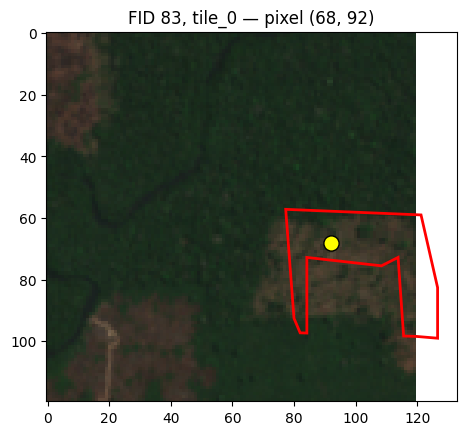

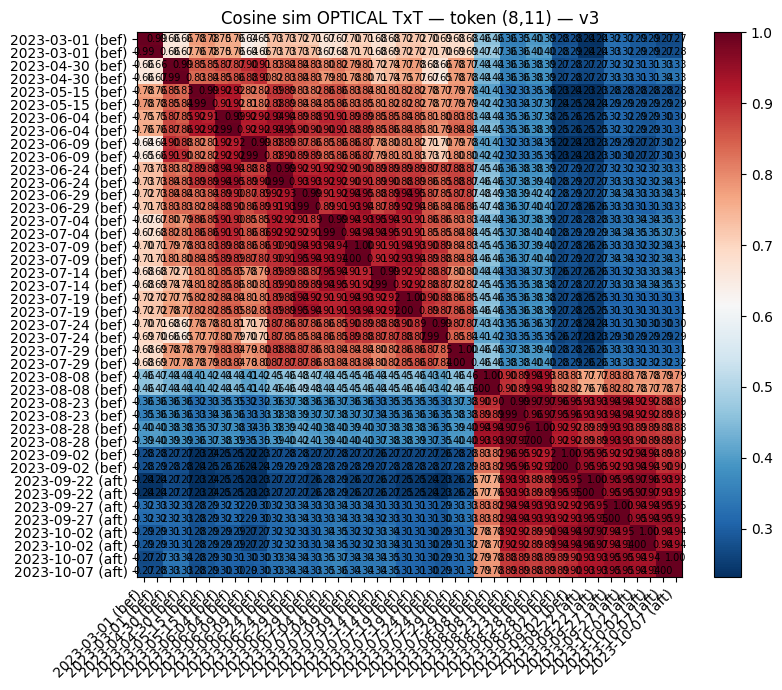

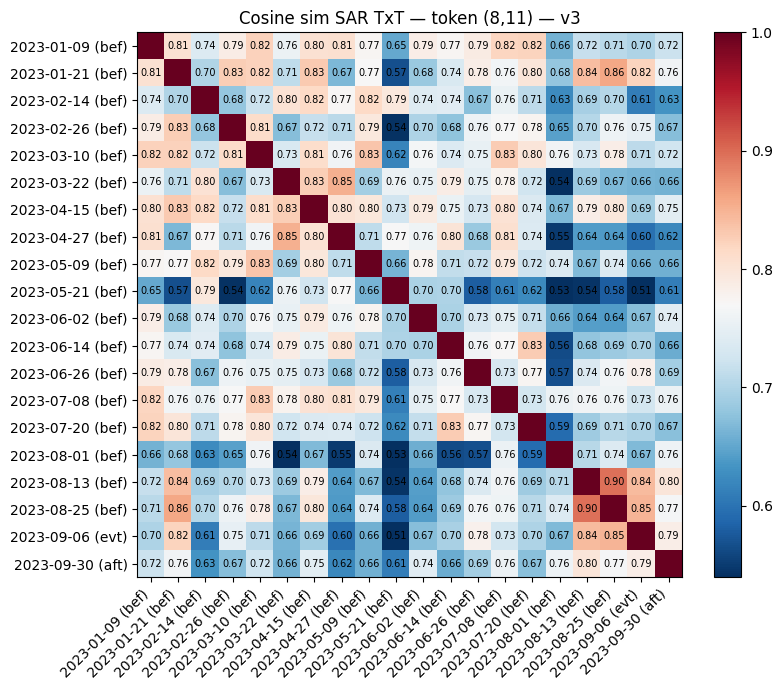

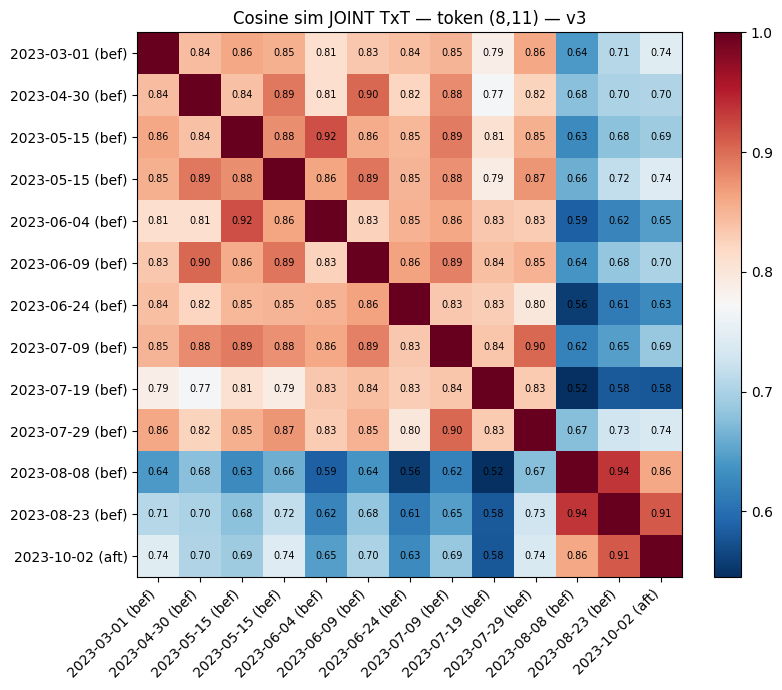

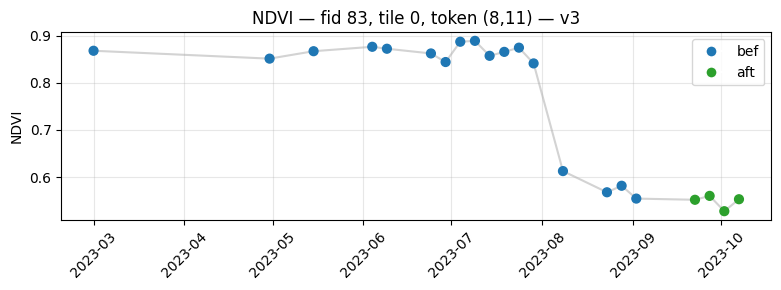

[optical] cube shape: (42, 15, 15, 768)
[optical] top dim: 328 (std=0.6589)
[optical] top 5 dims: [328, 146, 509, 470, 285]
[optical] top 5 scores: [0.6589000225067139, 0.6513000130653381, 0.5993000268936157, 0.58160001039505, 0.5620999932289124]


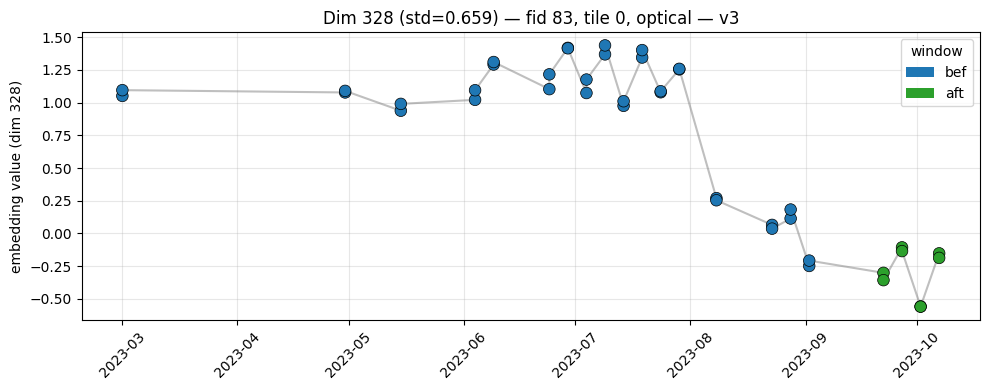

[optical] cube shape: (42, 15, 15, 768)
[optical] PCA on first image (225 tokens) — EVR=[0.19200000166893005, 0.12200000137090683, 0.1080000028014183]


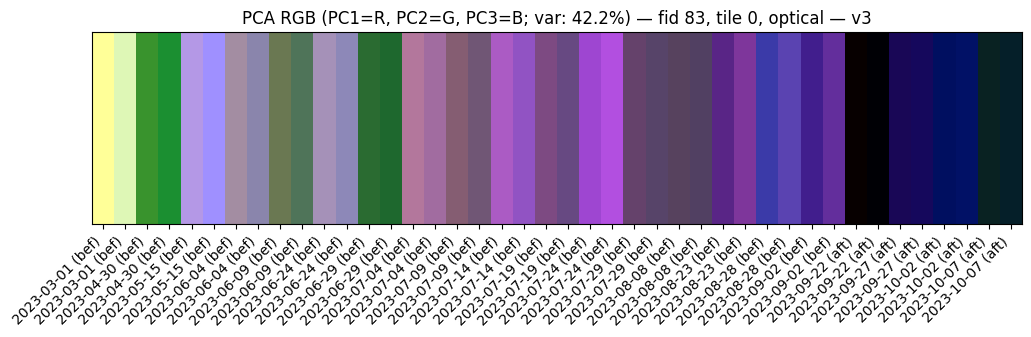

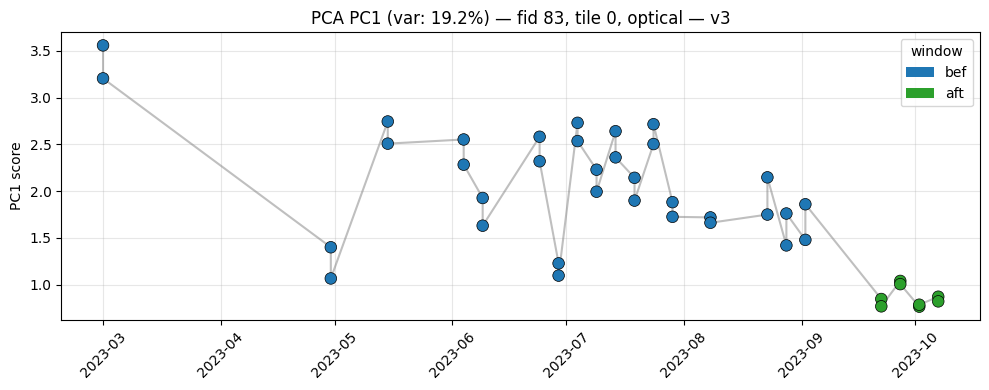

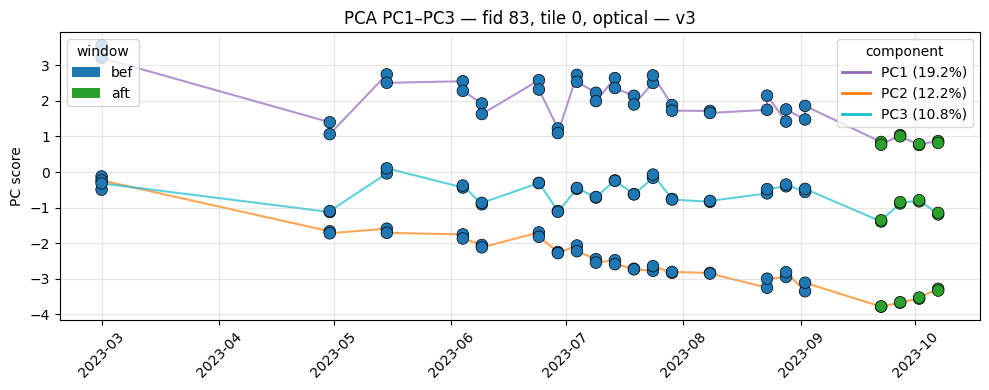

[sar] cube shape: (20, 15, 15, 768)
[sar] top dim: 498 (std=0.2266)
[sar] top 5 dims: [498, 253, 519, 487, 553]
[sar] top 5 scores: [0.22660000622272491, 0.2257000058889389, 0.1979999989271164, 0.1899999976158142, 0.18400000035762787]


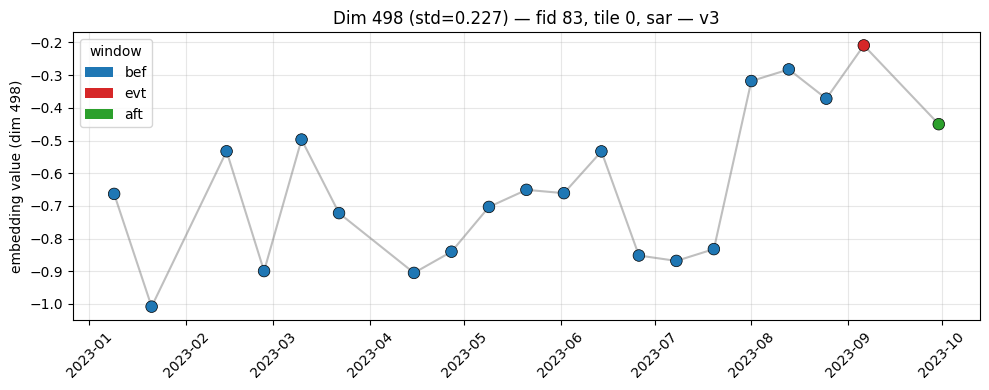

[sar] cube shape: (20, 15, 15, 768)
[sar] PCA on first image (225 tokens) — EVR=[0.14399999380111694, 0.10100000351667404, 0.08900000154972076]


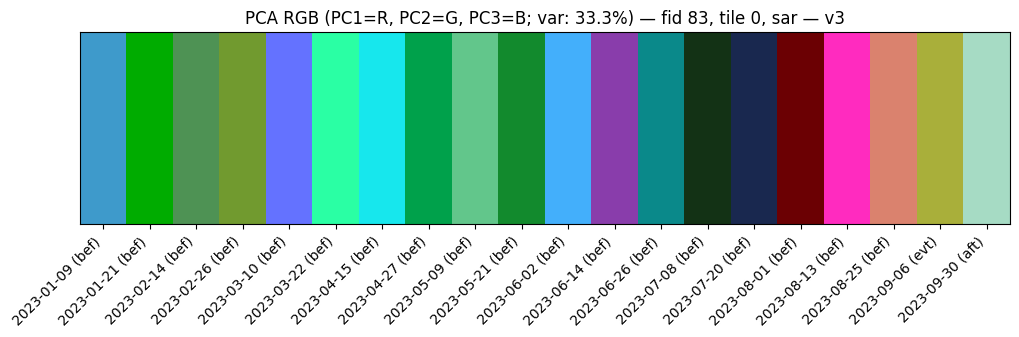

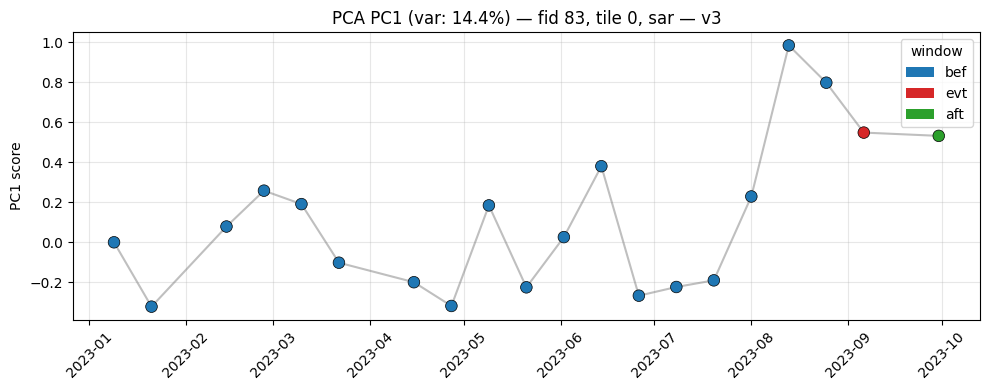

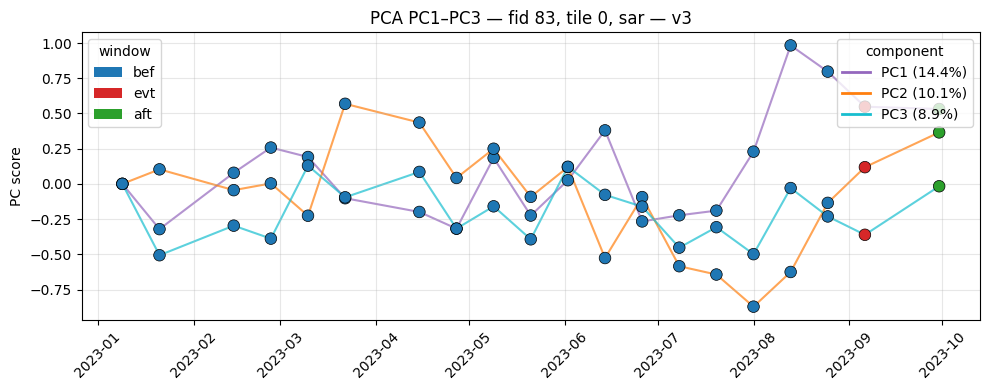

[joint] cube shape: (13, 15, 15, 768)
[joint] top dim: 437 (std=0.4601)
[joint] top 5 dims: [437, 524, 635, 723, 36]
[joint] top 5 scores: [0.460099995136261, 0.44519999623298645, 0.4156999886035919, 0.40610000491142273, 0.4007999897003174]


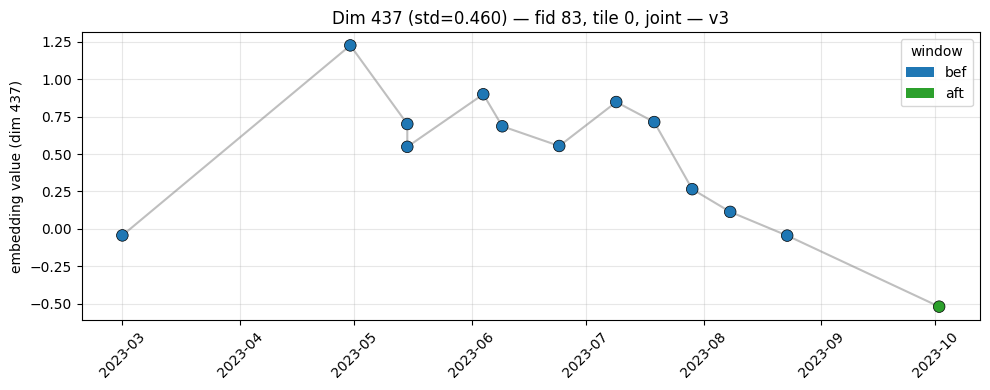

[joint] cube shape: (13, 15, 15, 768)
[joint] PCA on first image (225 tokens) — EVR=[0.20999999344348907, 0.16099999845027924, 0.09200000017881393]


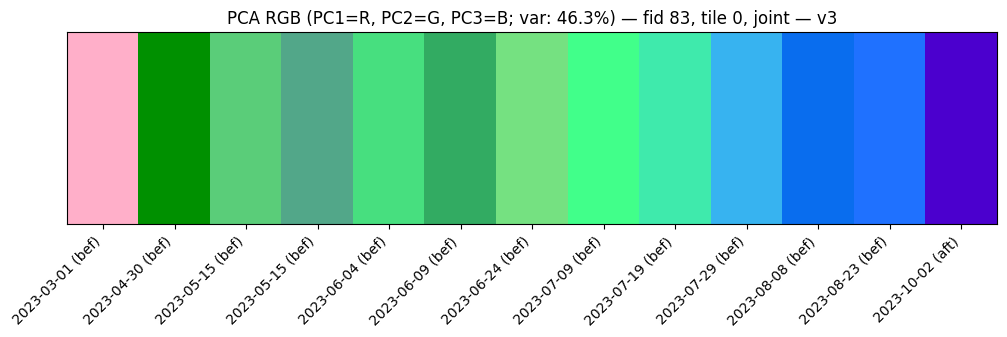

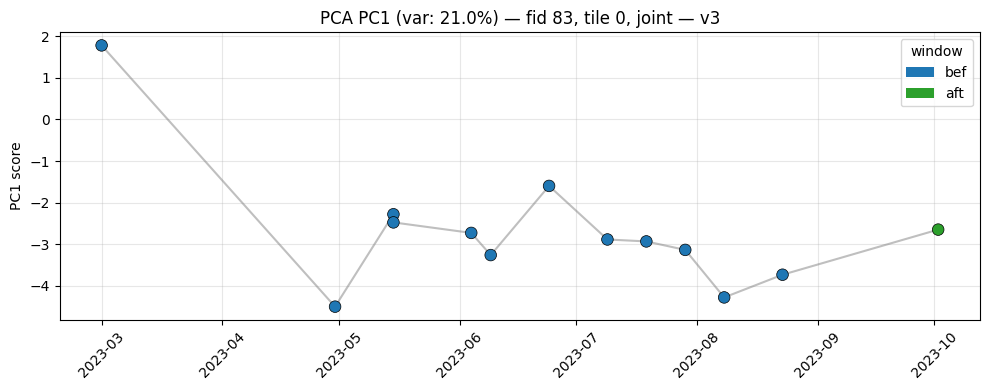

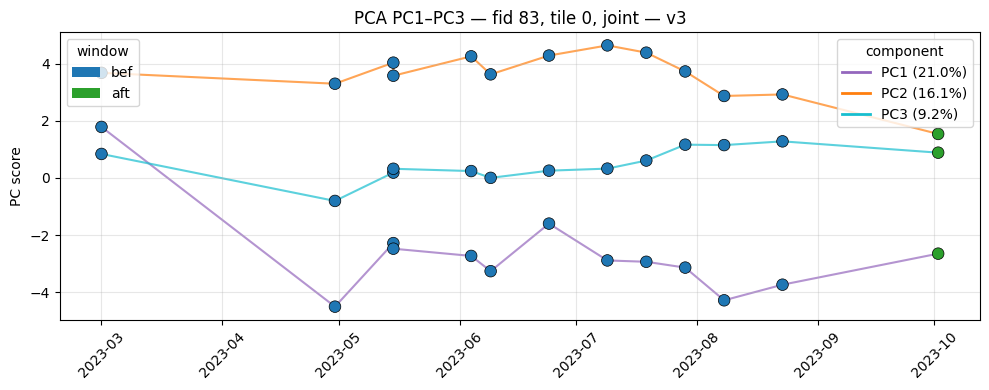

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.10966666666666666..1.7333333333333334].


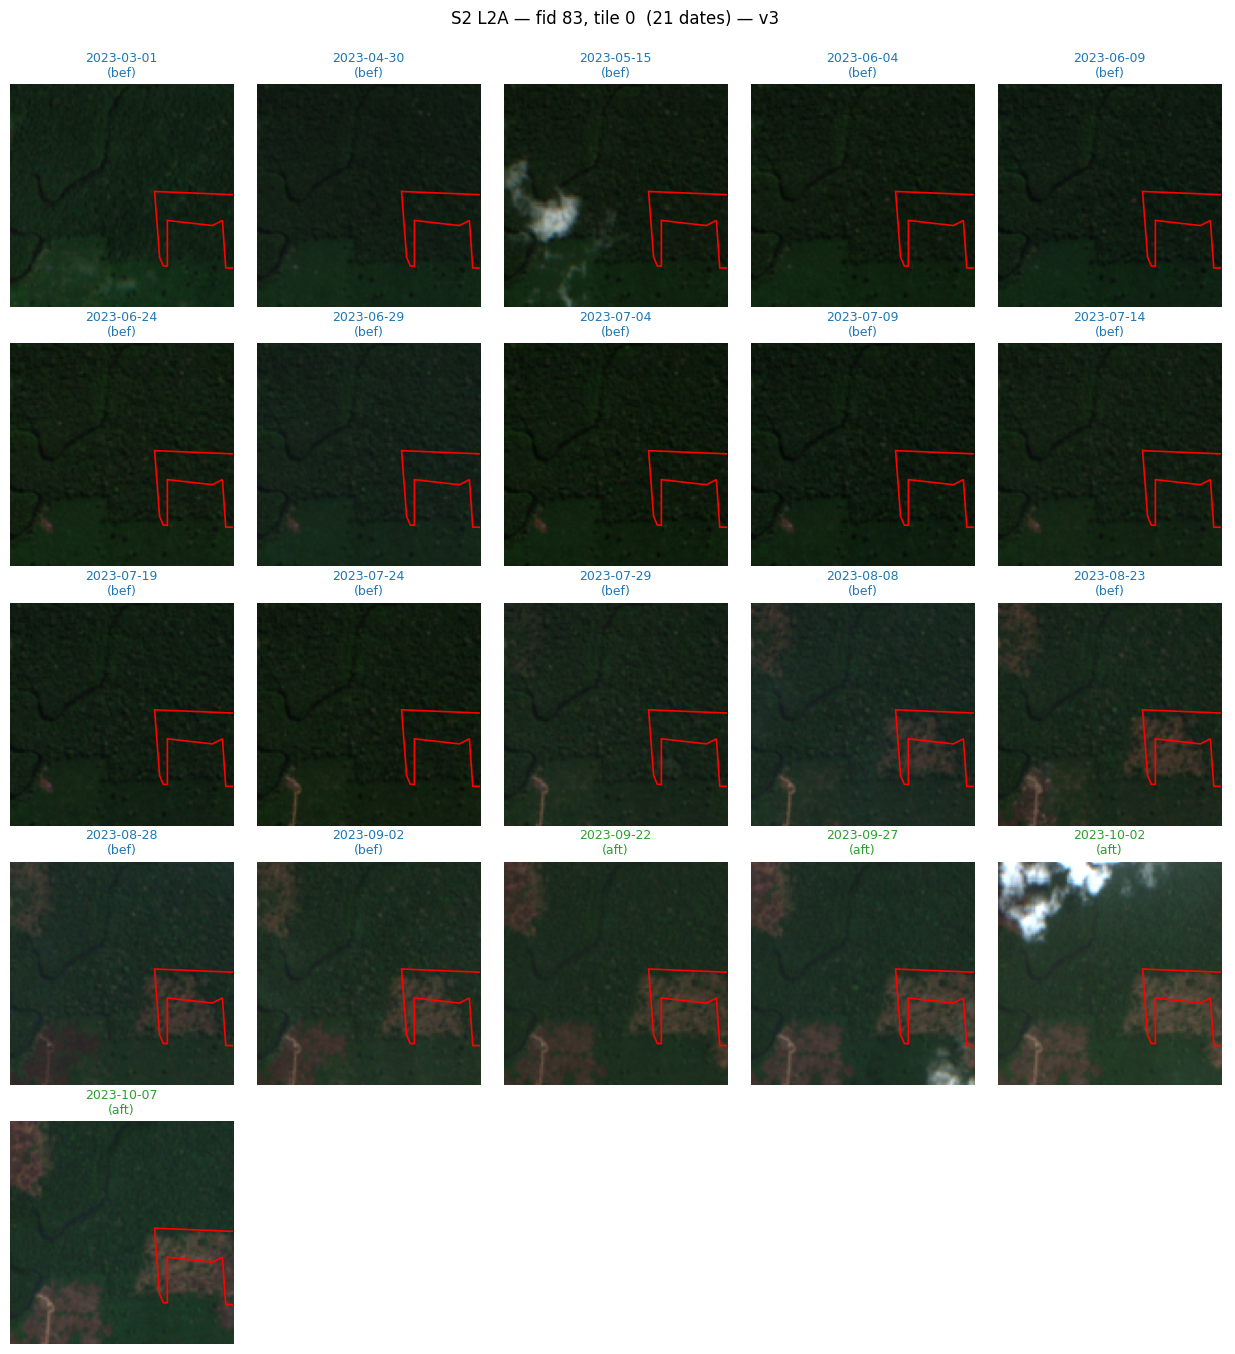

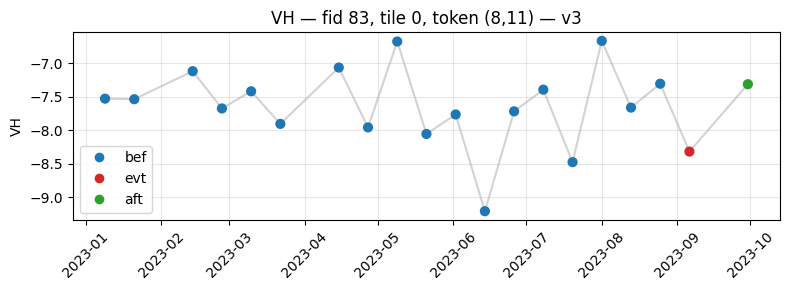

{'fid': 83,
 'tile': 0,
 'tok_r': 8,
 'tok_c': 11,
 'version': 'v3',
 'csv_path': 'data_csv/v3_images_s2_s1.csv',
 'n_allowed_s2': 42,
 'n_allowed_s1': 20}

In [2]:
#Clear-cut bare soil: FID 44: 84 images, FID 83: 74 images

run(fid=83, tile=0, version="v3", tok_r=8, tok_c=11)

In [ ]:
run(fid=83, tile=0, version="v2")

In [ ]:
run(fid=83, tile=0, version="v1")

In [ ]:
#Degradation:
  #FID 43: 50 images
  #FID 28: 48 images

run(fid=28, tile=0, version="v3")

In [ ]:
run(fid=28, tile=0, version="v2")

In [ ]:
run(fid=28, tile=0, version="v1")

In [12]:
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from sklearn.decomposition import PCA

from time_series_pipeline import (
    _allowed_ids_for_fid, _paths_for, _by_date_any, _by_win,
    _create_embeddings, WIN_COLORS, CSV_TEMPLATE, EMB_ROOT, SUBDIRS,
)


def _plot_series(ax, dates, values, colors, title, line_color="gray", label=None):
    """Time series on a given ax: background line + points colored by window."""
    ax.plot(dates, values, "-", color=line_color, alpha=0.6, zorder=1, label=label)
    ax.scatter(dates, values, c=colors, s=55, edgecolors="black", lw=0.5, zorder=3)
    ax.set_title(title)
    ax.tick_params(axis="x", rotation=45)
    ax.grid(alpha=0.3)


def compare_versions_mvd(fid, tok_r, tok_c, tile=0, modality="optical",
                        versions=("v1", "v2", "v3"), max_gap_days=7,
                        num_components=3):
    # make sure embeddings exist (resumable)
    _create_embeddings(fid, CSV_TEMPLATE.format(version="v3"), max_gap_days)

    # --- COMMON BASE: every image on disk for this fid/tile/modality ---
    subdir = SUBDIRS[modality]
    paths_all = sorted(glob.glob(f"{EMB_ROOT}/{subdir}/fid_{fid}/*/*/tile_{tile}.npy"),
                        key=_by_date_any)
    if not paths_all:
        print(f"[{modality}] no embeddings on disk — nothing to plot")
        return
    cube_all = np.stack([np.load(p) for p in paths_all])   # (T, R, C, D)
    _, R, C, D = cube_all.shape

    # fit PCA once on the first image's tokens (version-independent base)
    pca = PCA(n_components=num_components).fit(cube_all[0].reshape(R * C, D))
    evr = pca.explained_variance_ratio_

    # most-variable dim: fixed from the full set, FOR THIS TOKEN
    top = int(cube_all[:, tok_r, tok_c, :].std(axis=0).argmax())

    nver = len(versions)
    fig, axes = plt.subplots(3, nver, figsize=(6 * nver, 12), squeeze=False)
    pc_colors = ["tab:purple", "tab:orange", "tab:cyan"]

    for j, version in enumerate(versions):
        ax_mvd, ax_pc1, ax_pc13 = axes[0, j], axes[1, j], axes[2, j]

        allowed = _allowed_ids_for_fid(CSV_TEMPLATE.format(version=version), fid)
        paths = _paths_for(fid, tile, modality, allowed["s2"], allowed["s1"])
        if not paths:
            for ax in (ax_mvd, ax_pc1, ax_pc13):
                ax.set_title(f"{version}: no data"); ax.axis("off")
            continue

        cube = np.stack([np.load(p) for p in paths])       # filtered cube
        dates = pd.to_datetime([_by_date_any(p) for p in paths])
        colors = [WIN_COLORS[_by_win(p)] for p in paths]
        token = cube[:, tok_r, tok_c, :]                   # (T, D) — single token series
        scores = pca.transform(token)                      # project token onto common base

        # row 1: most variable dim of this token (same 'top' dim across versions)
        _plot_series(ax_mvd, dates, token[:, top], colors,
                    f"{version} — dim {top} (n={len(paths)})")

        # row 2: PC1
        _plot_series(ax_pc1, dates, scores[:, 0], colors,
                    f"{version} — PC1 (var {evr[0]:.1%})")

        # row 3: PC1-PC3 (line per component, points per window)
        for k in range(num_components):
            _plot_series(ax_pc13, dates, scores[:, k], colors,
                        f"{version} — PC1-PC3", line_color=pc_colors[k],
                        label=f"PC{k+1} ({evr[k]:.1%})")
        ax_pc13.legend(title="component", fontsize=8, loc="upper right")

    fig.legend(handles=[Patch(facecolor=c, label=w) for w, c in WIN_COLORS.items()],
                title="window", loc="upper left")
    fig.suptitle(f"MVD + PCA (token {tok_r},{tok_c}, common base) — "
                f"fid {fid}, tile {tile}, {modality}", y=1.0)
    plt.tight_layout(); plt.show()

[done] All embeddings already exist in /share/castor/home/e2406749/tropical_forest_disturbance/embeddings/s2_l2a/fid_83/aft/20230922T142711_20230922T142743_T20LMR
[done] All embeddings already exist in /share/castor/home/e2406749/tropical_forest_disturbance/embeddings/s2_l2a/fid_83/aft/20230927T142719_20230927T142849_T20LMR
[done] All embeddings already exist in /share/castor/home/e2406749/tropical_forest_disturbance/embeddings/s2_l2a/fid_83/aft/20231002T142711_20231002T143108_T20LMR
[done] All embeddings already exist in /share/castor/home/e2406749/tropical_forest_disturbance/embeddings/s2_l2a/fid_83/aft/20231007T142709_20231007T142929_T20LMR
[done] All embeddings already exist in /share/castor/home/e2406749/tropical_forest_disturbance/embeddings/s2_l2a/fid_83/bef/20230115T142711_20230115T142817_T20LMR
[done] All embeddings already exist in /share/castor/home/e2406749/tropical_forest_disturbance/embeddings/s2_l2a/fid_83/bef/20230214T142711_20230214T143425_T20LMR
[done] All embeddings 

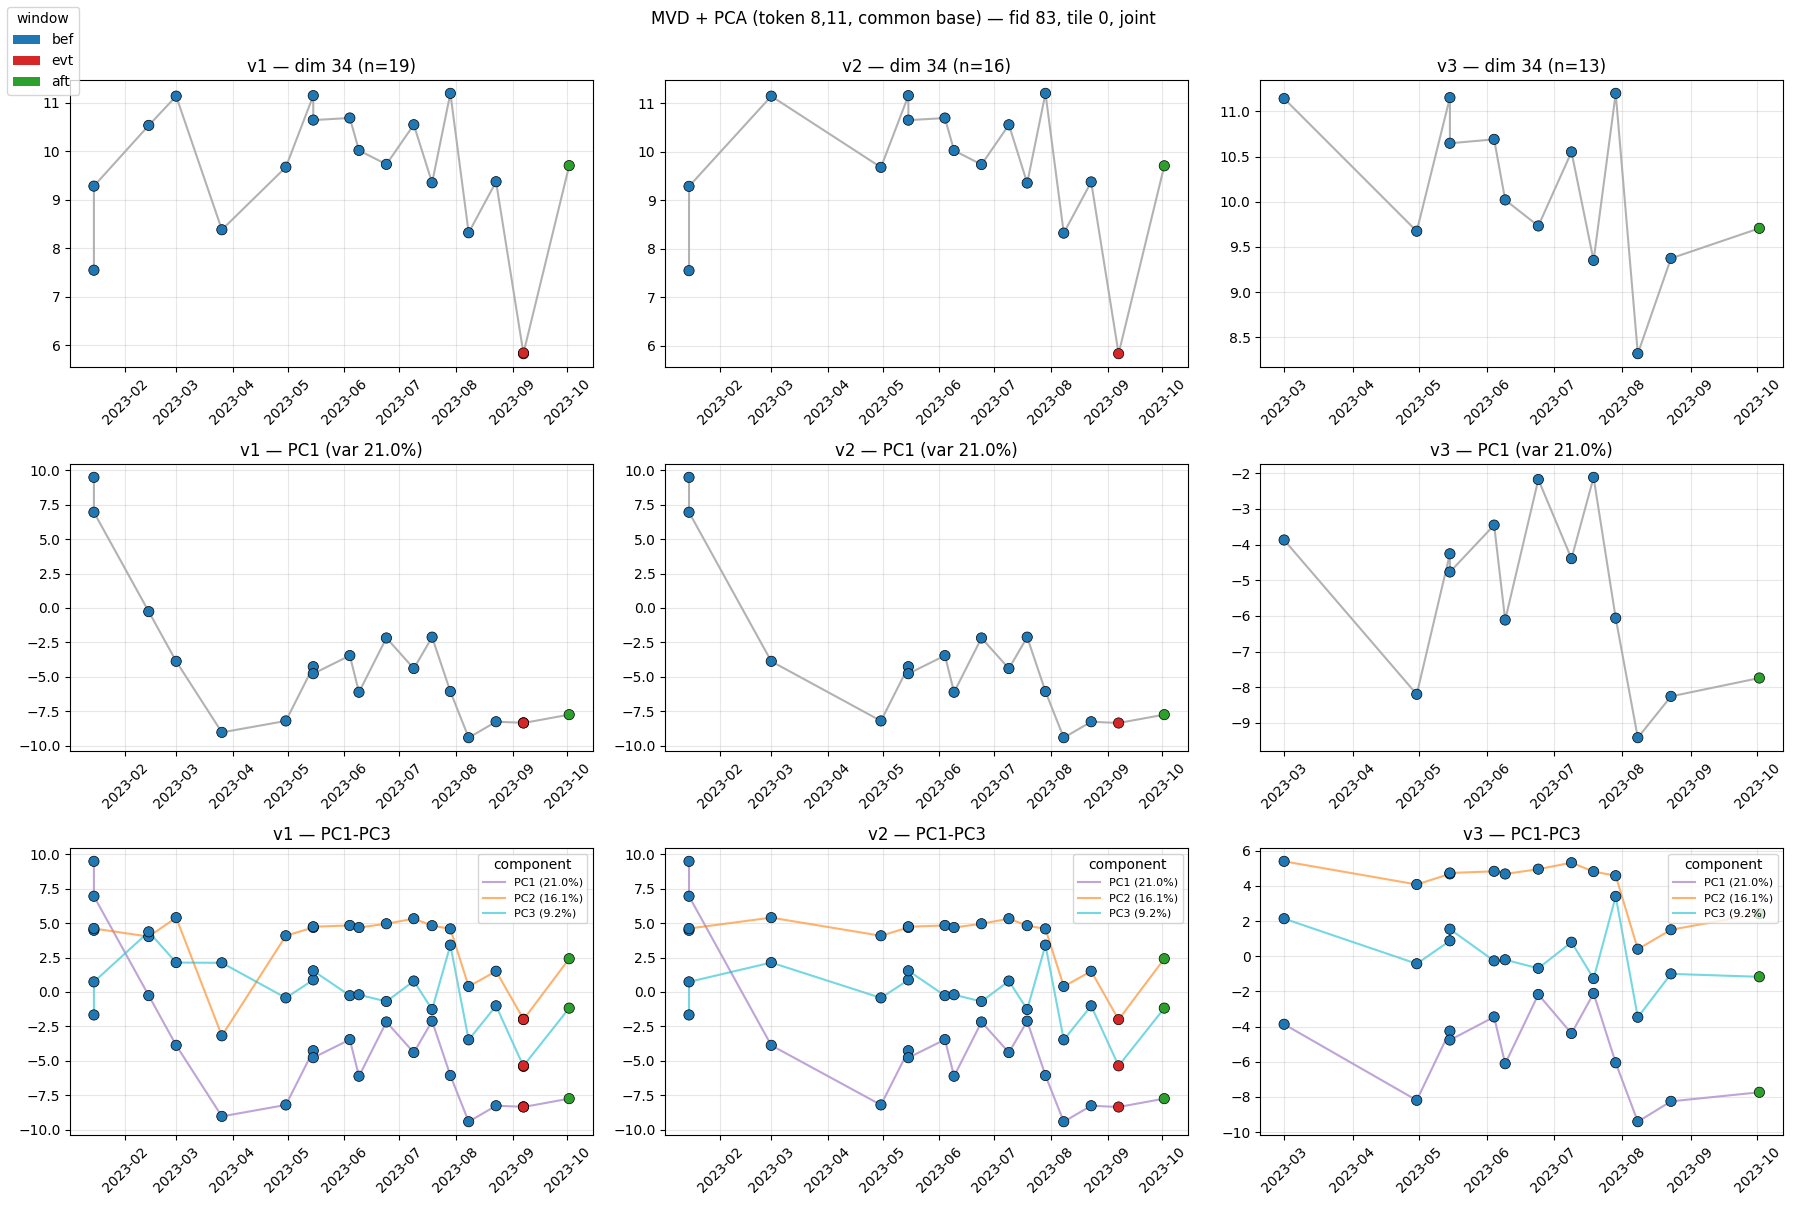

In [9]:
compare_versions_mvd(fid=83, tile=0, modality="joint",tok_r=8, tok_c=11)

In [ ]:
compare_versions_mvd(fid=83, tile=0, modality="sar")

In [15]:
def compare_mvd(fid, tok_r, tok_c, tile=0, modalities=("optical", "sar", "joint")):
      for m in modalities:
          compare_versions_mvd(fid, tok_r=tok_r, tok_c=tok_c, tile=tile, modality=m)

[done] All embeddings already exist in /share/castor/home/e2406749/tropical_forest_disturbance/embeddings/s2_l2a/fid_83/aft/20230922T142711_20230922T142743_T20LMR
[done] All embeddings already exist in /share/castor/home/e2406749/tropical_forest_disturbance/embeddings/s2_l2a/fid_83/aft/20230927T142719_20230927T142849_T20LMR
[done] All embeddings already exist in /share/castor/home/e2406749/tropical_forest_disturbance/embeddings/s2_l2a/fid_83/aft/20231002T142711_20231002T143108_T20LMR
[done] All embeddings already exist in /share/castor/home/e2406749/tropical_forest_disturbance/embeddings/s2_l2a/fid_83/aft/20231007T142709_20231007T142929_T20LMR
[done] All embeddings already exist in /share/castor/home/e2406749/tropical_forest_disturbance/embeddings/s2_l2a/fid_83/bef/20230115T142711_20230115T142817_T20LMR
[done] All embeddings already exist in /share/castor/home/e2406749/tropical_forest_disturbance/embeddings/s2_l2a/fid_83/bef/20230214T142711_20230214T143425_T20LMR
[done] All embeddings 

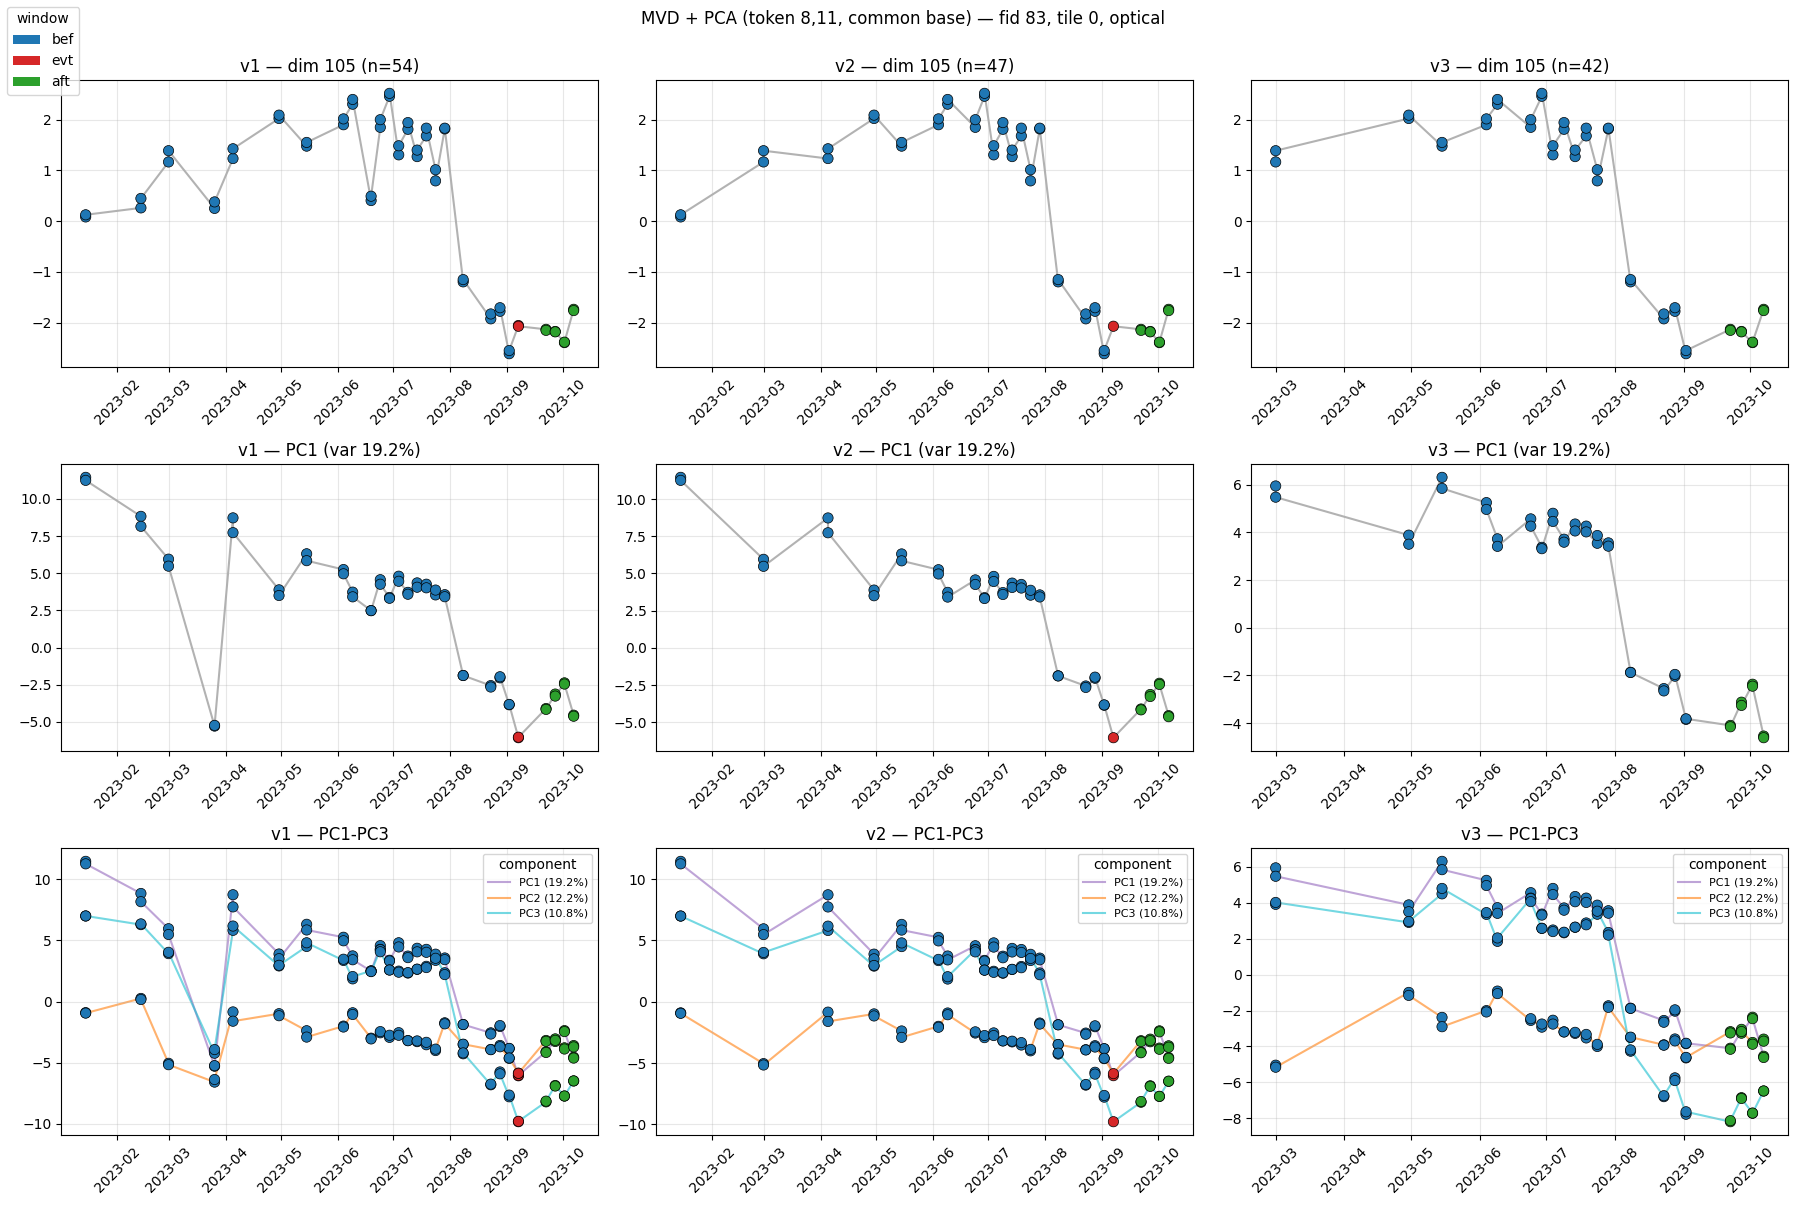

[done] All embeddings already exist in /share/castor/home/e2406749/tropical_forest_disturbance/embeddings/s2_l2a/fid_83/aft/20230922T142711_20230922T142743_T20LMR
[done] All embeddings already exist in /share/castor/home/e2406749/tropical_forest_disturbance/embeddings/s2_l2a/fid_83/aft/20230927T142719_20230927T142849_T20LMR
[done] All embeddings already exist in /share/castor/home/e2406749/tropical_forest_disturbance/embeddings/s2_l2a/fid_83/aft/20231002T142711_20231002T143108_T20LMR
[done] All embeddings already exist in /share/castor/home/e2406749/tropical_forest_disturbance/embeddings/s2_l2a/fid_83/aft/20231007T142709_20231007T142929_T20LMR
[done] All embeddings already exist in /share/castor/home/e2406749/tropical_forest_disturbance/embeddings/s2_l2a/fid_83/bef/20230115T142711_20230115T142817_T20LMR
[done] All embeddings already exist in /share/castor/home/e2406749/tropical_forest_disturbance/embeddings/s2_l2a/fid_83/bef/20230214T142711_20230214T143425_T20LMR
[done] All embeddings 

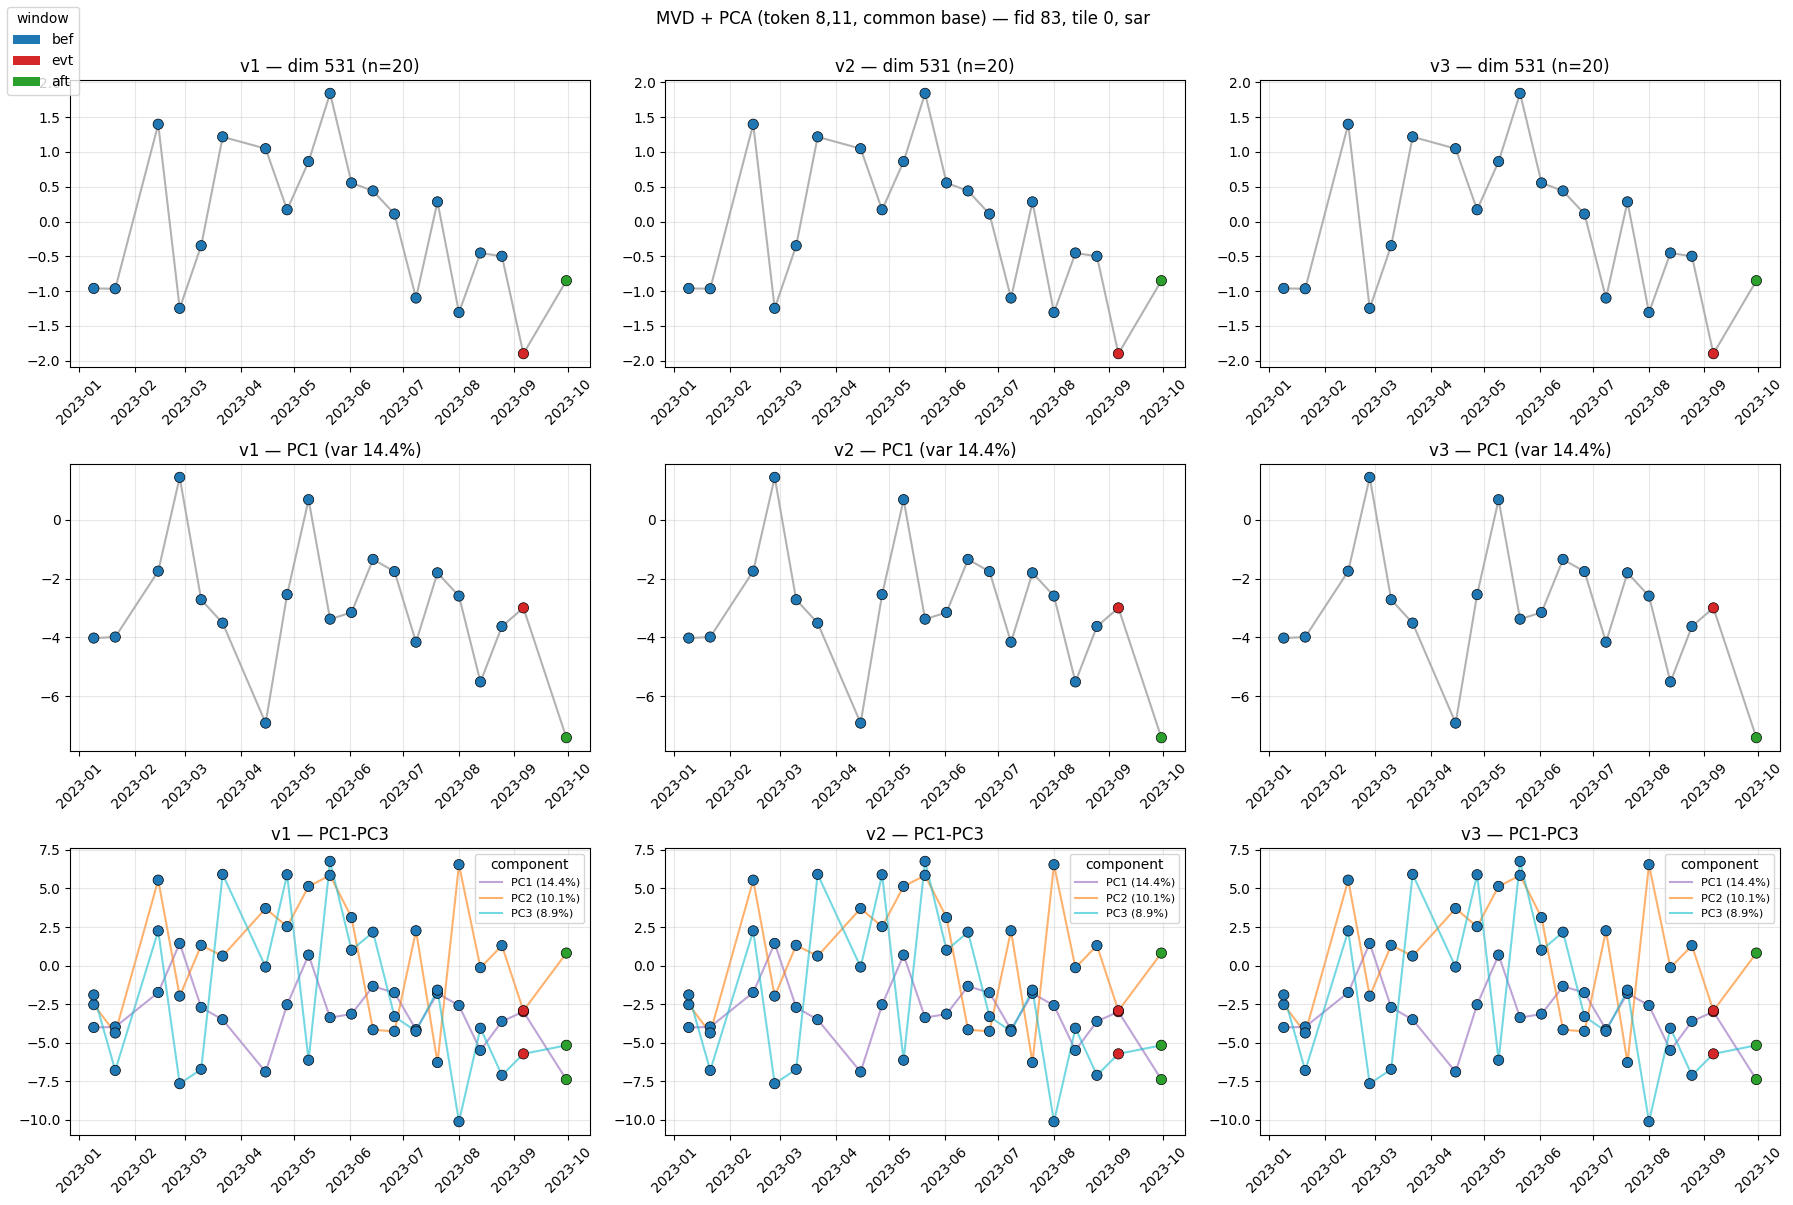

[done] All embeddings already exist in /share/castor/home/e2406749/tropical_forest_disturbance/embeddings/s2_l2a/fid_83/aft/20230922T142711_20230922T142743_T20LMR
[done] All embeddings already exist in /share/castor/home/e2406749/tropical_forest_disturbance/embeddings/s2_l2a/fid_83/aft/20230927T142719_20230927T142849_T20LMR
[done] All embeddings already exist in /share/castor/home/e2406749/tropical_forest_disturbance/embeddings/s2_l2a/fid_83/aft/20231002T142711_20231002T143108_T20LMR
[done] All embeddings already exist in /share/castor/home/e2406749/tropical_forest_disturbance/embeddings/s2_l2a/fid_83/aft/20231007T142709_20231007T142929_T20LMR
[done] All embeddings already exist in /share/castor/home/e2406749/tropical_forest_disturbance/embeddings/s2_l2a/fid_83/bef/20230115T142711_20230115T142817_T20LMR
[done] All embeddings already exist in /share/castor/home/e2406749/tropical_forest_disturbance/embeddings/s2_l2a/fid_83/bef/20230214T142711_20230214T143425_T20LMR
[done] All embeddings 

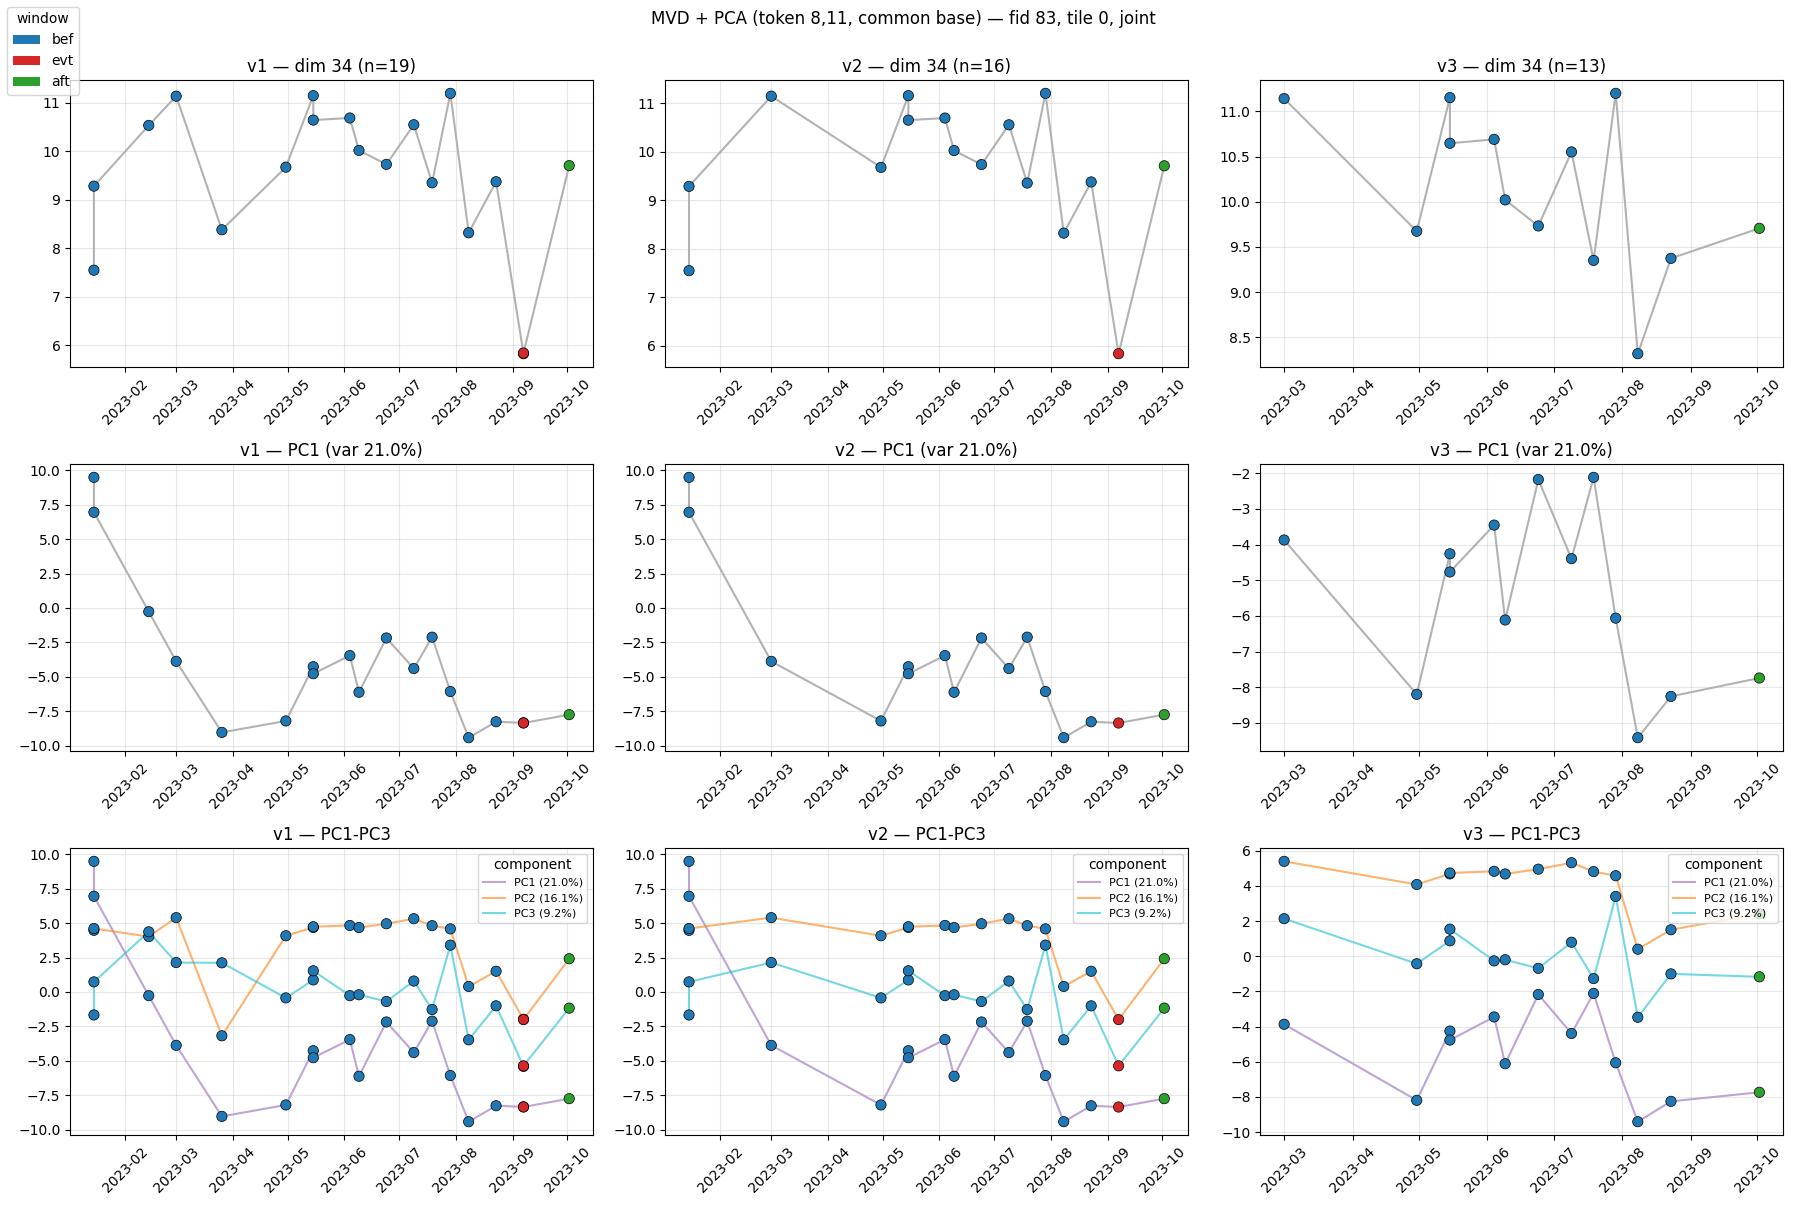

In [16]:
compare_mvd(fid=83, tile=0, modalities=("optical", "sar", "joint"), tok_r=8, tok_c=11)

In [ ]:
compare_mvd(28, modalities=["optical", "sar", "joint"])

In [ ]:
compare_mvd(363, modalities=["optical", "sar", "joint"])

In [ ]:
run(fid=363, tile=2,version="v1")

In [ ]:
run(fid=363, tile=2,version="v2")

In [ ]:
run(fid=363, tile=2,version="v3")

In [ ]:
compare_mvd(363, tile=2, modalities=["optical", "sar", "joint"])

In [ ]:
run(fid=63, tile=2,version="v1")

In [ ]:
run(fid=63, tile=2,version="v2")

In [ ]:
run(fid=63, tile=2,version="v3")

In [ ]:
top2_fids = [83, 380, 389, 359, 318, 236, 11, 10, 371, 60, 78, 384]